# Ridge 연도 기반 훈련 데이터 분할

(1) 라이브러리 임포트 및 한글 폰트 설정

In [10]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

matplotlib.rc('font', family='Malgun Gothic')
matplotlib.rc('axes', unicode_minus=False)

(2) 데이터 불러오기

In [ ]:
folder_path = r"C:\Users\user22\Desktop\아파트 값 예측\data"
df = pd.read_csv(folder_path + r"\real_new_city.csv", encoding='utf-8-sig')

(3) 전처리

In [12]:
# 거래금액 쉼표 제거 후 정수 변환
df['거래금액(만원)'] = df['거래금액(만원)'].str.replace(',', '').astype(int)
# 전용면적당 가격 계산
df['m2당가격'] = df['거래금액(만원)'] / df['전용면적(㎡)']

# 2025년 이하 데이터만 사용
df = df[df['계약연도'] <= 2025]
print(f"2025년 이하 데이터: {len(df)}건")

2025년 이하 데이터: 122354건


(4) 이상치 제거

In [13]:
# 10평 넘는 데이터 제거
print(f"이상치 제거 전 데이터 건수: {len(df)}")
df = df[df['전용면적(㎡)'] >= 33]
print(f"전용면적 33㎡ 미만 제거 후: {len(df)}")

# 발표후경과년수 3년미만 필터링
before = len(df)
df = df[df['발표후경과년수'] >= 3]
print(f"발표후경과년수 3 미만 제거: {before - len(df)}개 → 남은 데이터: {len(df)}개")

# z-score
mean = df['m2당가격'].mean()
std = df['m2당가격'].std()
z_scores = (df['m2당가격'] - mean) / std
df = df[z_scores.abs() <= 2]
print(f"z-score 이상치 제거 후: {len(df)}")

이상치 제거 전 데이터 건수: 122354
전용면적 33㎡ 미만 제거 후: 122063
발표후경과년수 3 미만 제거: 3863개 → 남은 데이터: 118200개
z-score 이상치 제거 후: 113033


(5) 독립변수/타겟 설정

In [14]:
# 모델 학습에 사용할 독립변수 목록
features = ['건축년도', '층',
            '지하철호선개수', '기차역까지의거리',
            '가장 가까운 지하철역까지의 거리', '가장 가까운 IC와의 거리',
            '발표후경과년수', 'CPI', '계약연도', '서울도심거리',
            '단지별_세대수', '도시별_세대수']

df = df.dropna(subset=features + ['m2당가격'])
print(f"결측치 제거 후 데이터 건수: {len(df)}")

결측치 제거 후 데이터 건수: 113029


(6) 훈련/테스트 분할 및 표준화

In [15]:
df_train = df[df['계약연도'] <= 2023]
df_test = df[df['계약연도'] >= 2024]

train_input = df_train[features]
train_target = df_train['m2당가격']
test_input = df_test[features]
test_target = df_test['m2당가격']

print(f"훈련 세트 크기: {train_input.shape}")
print(f"테스트 세트 크기: {test_input.shape}")

# 표준화
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

훈련 세트 크기: (96648, 12)
테스트 세트 크기: (16381, 12)


(7) Ridge 모델 학습

In [16]:
ridge = Ridge()
ridge.fit(train_scaled, train_target)

print(f"훈련 세트 R²: {ridge.score(train_scaled, train_target):.4f}")
print(f"테스트 세트 R²: {ridge.score(test_scaled, test_target):.4f}")

훈련 세트 R²: 0.6756
테스트 세트 R²: 0.5724


(8) alpha 탐색 및 그래프 보기

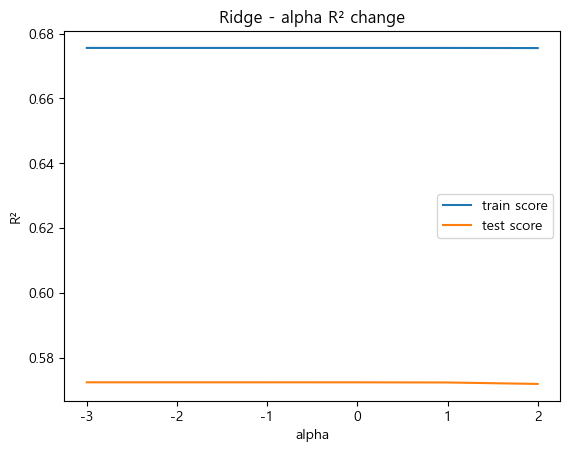

In [17]:
train_score = []
test_score = []
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]

for alpha in alpha_list:
    ridge_a = Ridge(alpha=alpha)
    ridge_a.fit(train_scaled, train_target)
    train_score.append(ridge_a.score(train_scaled, train_target))
    test_score.append(ridge_a.score(test_scaled, test_target))

plt.plot(np.log10(alpha_list), train_score, label='train score')
plt.plot(np.log10(alpha_list), test_score, label='test score')
plt.xlabel('alpha')
plt.ylabel('R²')
plt.legend()
plt.title('Ridge - alpha R² change')
plt.show()

(9) 최적 alpha로 최종 모델 학습

In [18]:
best_idx = test_score.index(max(test_score))
best_alpha = alpha_list[best_idx]
print(f"최적 alpha: {best_alpha}")

ridge_best = Ridge(alpha=best_alpha)
ridge_best.fit(train_scaled, train_target)
print(f"최적 alpha 훈련 세트 R²: {ridge_best.score(train_scaled, train_target):.4f}")
print(f"최적 alpha 테스트 세트 R²: {ridge_best.score(test_scaled, test_target):.4f}")

최적 alpha: 0.001
최적 alpha 훈련 세트 R²: 0.6756
최적 alpha 테스트 세트 R²: 0.5724
